### Importação das Bibliotecas

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos Dados com CSV

In [19]:
# try: 
#     # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows
#     # dados = np.loadtxt('.csv', delimiter=',', skiprows=1, usecols=(2, 3)) 
# except FileNotFoundError:
#     print("Erro: arquivo 'dataset.csv' não encontrado")
#     print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
#     exit()

In [20]:
# apenas visualiza os dados carregados do arquivo CSV
# print(dados)

### Separando os dados e X e Y

In [4]:
# criando dados (já que não há dataset para usar como base)
# X = variável independente (anos de experiência)
# Y = variável dependente a ser prevista (salário em R$)
x = np.array([6, 2, 1, 5, 3]) # Treinamentos
y = np.array([15, 4, 2, 12, 7]) # Produtividade mensal

# Visualiza os dados
print('Treinamentos técnicos(X):', x)
print('Produtividade Mensal (Y):', y)

print("\nNúmero de amostras: ", x.shape[0])

Treinamentos técnicos(X): [6 2 1 5 3]
Produtividade Mensal (Y): [15  4  2 12  7]

Número de amostras:  5


In [5]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print('X:', x)
print('\nY:', y)

# Descomente a linha abaixo se quiser ver detalhes dos dados

#print('Número de características:', x.reshape[1])
#print('Número de saídas)

X: [[6]
 [2]
 [1]
 [5]
 [3]]

Y: [[15]
 [ 4]
 [ 2]
 [12]
 [ 7]]


### Calculando 'A' e 'B'

In [6]:
# Calcular os coeficientes da regressão linear (A e B)
x_mean = np.mean(x)
y_mean = np.mean(y)

print('Média de X:', x_mean)
print('Média de Y:', y_mean)

Média de X: 3.4
Média de Y: 8.0


In [24]:
def predict(x_novo, _m, _b):
    """
    Prevê novos valores de y com base nos coeficientes da regressão.
    Args:
        x_novo: Um número ou array NumPy com os novos valores de x.
        m: Coeficiente angular (slope) do modelo.
        b: O intercepto do modelo
    Returns: O(s) valor(es) de y previstos
    """
    return _m * x_novo + _b

Coeficientes calculados a partir do CSV: 
Coeficiente angular (m): 2.6163
Intercepto (b) -0.8953

Equação da linha: y = 2.6163x + -0.8953

Coeficiente de Determinação (R²): 0.9977
O modelo tem um bom ajuste aos dados.


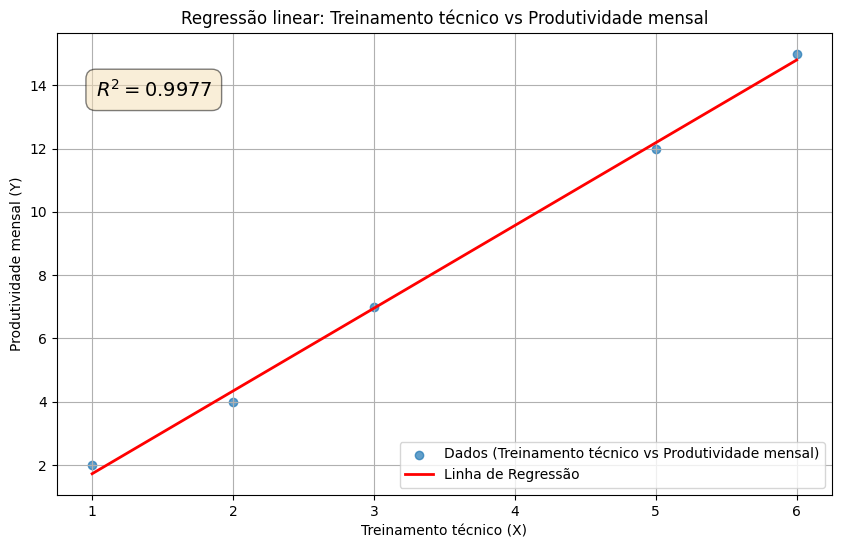

In [10]:
m = len(x)
numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)

m = numerador / denominador
b = y_mean - (m * x_mean)

# Fazer as previsões do modelo
# Para cada valor de x, calculamos o y previsto (^y) pela nossa linha.
y_pred = m * x + b

# Calcular o R-quadrado (R²) para avaliar o modelo 
sqr = np.sum((y - y_pred) ** 2) # Soma quadrática dos resíduos
sqt = np.sum((y - y_mean) ** 2) # Soma quadrática total
r2 = 1 - (sqr / sqt)

# Imprimir os resultados
print(f"Coeficientes calculados a partir do CSV: ")
print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b) {b:.4f}")
print("\nEquação da linha: y = {:.4f}x + {:.4f}".format(m, b))
print(f"\nCoeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print('O modelo tem um bom ajuste aos dados.')
elif r2 > 0.5:
    print('O modelo tem um ajuste moderado')
else:
    print('O modelo tem um ajuste fraco')

# Criar a linha de regressão para Visualização
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

# Visualizar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados (Treinamento técnico vs Produtividade mensal)', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

# Adiciona o valor R² ao gráfico para fácil vizualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title("Regressão linear: Treinamento técnico vs Produtividade mensal")
plt.xlabel('Treinamento técnico (X)')
plt.ylabel('Produtividade mensal (Y)')
plt.legend()
plt.grid(True)
plt.show()